In [1]:
# import necessary dependancies
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# create plotting logic and set seed
rng = np.random.default_rng(4360)
M = 5000

def hist_vs_pdf (samples, x, pdf, title, label, bins  = 60, range_ = None, extra = None):
    """Density-nomalized hnistrogram with a theoretical PDF overlay."""
    
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(samples, bins=bins, range=range_, density=True,
            alpha=0.5, edgecolor="white", label=f"Simulated (M={len(samples)})")
    ax.plot(x, pdf, "r-", lw=2, label=label)
    
    # optional extra curve
    if extra:
        ax.plot(x, extra[0], "k--", lw=1.5, label=extra[1])

    ax.set_title(title)
    ax.set_ylabel("Density")
    ax.legend()
    plt.show()


mean 15.00 (thoery 15), var 31.28 (theory 30)


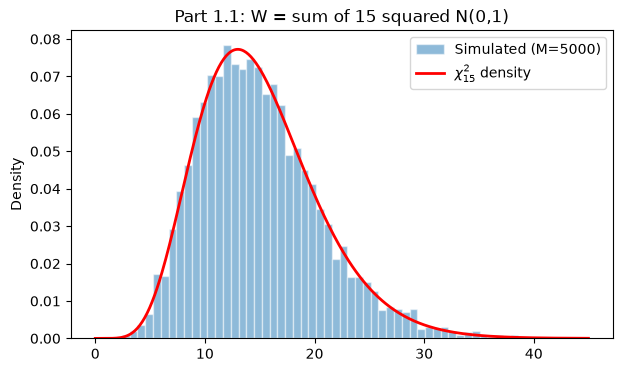

In [ ]:
# Part 1.1 Chi-square
n = 15
Z = rng.standard_normal((M, n))
W = (Z**2).sum(axis=1)

print(f"mean {W.mean():.2f} (theory {n}), var {W.var():.2f} (theory {2*n})")

x = np.linspace(0, W.max(), 400)
hist_vs_pdf(W, x, stats.chi2.pdf(x, df=n),
            "Part 1.1: W = sum of 15 squared N(0,1)", r"$\chi^2_{15}$ density")

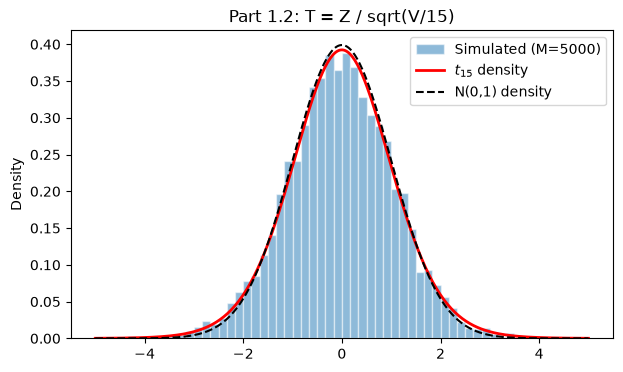

In [4]:
# Part 1.2 t distribution
n = 15 
Zo = rng.standard_normal(M)
V = (rng.standard_normal((M,n))**2).sum(axis=1)
T = Zo / np.sqrt(V/n)

x = np.linspace(-5, 5, 400)
hist_vs_pdf(T, x, stats.t.pdf(x, df=n),
            "Part 1.2: T = Z / sqrt(V/15)", r"$t_{15}$ density",
            range_=(-5, 5),
            extra=(stats.norm.pdf(x), "N(0,1) density"))

In [5]:
# Part 1.2 tail check: how often |T| > 3, simulated vs t15 vs normal
print("P(|T|>3) sim:", np.mean(np.abs(T) > 3),
      " t15:", round(2*stats.t.sf(3, 15), 4),
      " normal:", round(2*stats.norm.sf(3), 4))

P(|T|>3) sim: 0.0092  t15: 0.009  normal: 0.0027


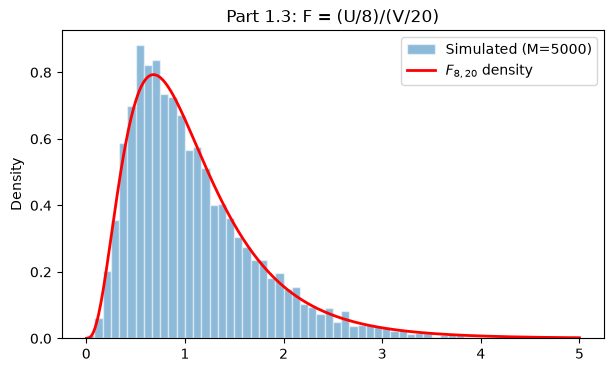

In [6]:
# Part 1.3 F distribution
n1, n2 = 8, 20
U = (rng.standard_normal((M, n1))**2).sum(axis=1)
V = (rng.standard_normal((M, n2))**2).sum(axis=1)
F = (U / n1) / (V / n2)

x = np.linspace(0.001, 5, 400)
hist_vs_pdf(F, x, stats.f.pdf(x, dfn=n1, dfd=n2),
            "Part 1.3: F = (U/8)/(V/20)", r"$F_{8,20}$ density", range_=(0, 5))

In [7]:
# Part 2: one real sample, estimate mean and variance from it
n, mu, sigma = 20, 5, 2
X = rng.normal(mu, sigma, size=(M, n))      # each row = one sample

xbar = X.mean(axis=1)
S2   = X.var(axis=1, ddof=1)                 # ddof=1 -> divide by n-1

W_prime = (n - 1) * S2 / sigma**2
T_prime = np.sqrt(n) * (xbar - mu) / np.sqrt(S2)

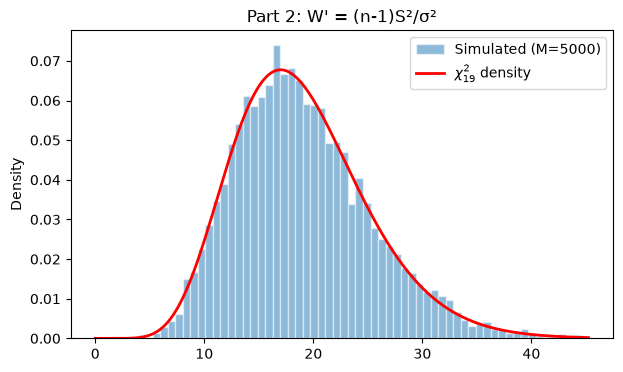

In [8]:
# Part 2: W' vs chi-square with n-1 df
x = np.linspace(0, W_prime.max(), 400)
hist_vs_pdf(W_prime, x, stats.chi2.pdf(x, df=n-1),
            "Part 2: W' = (n-1)S²/σ²", r"$\chi^2_{19}$ density")

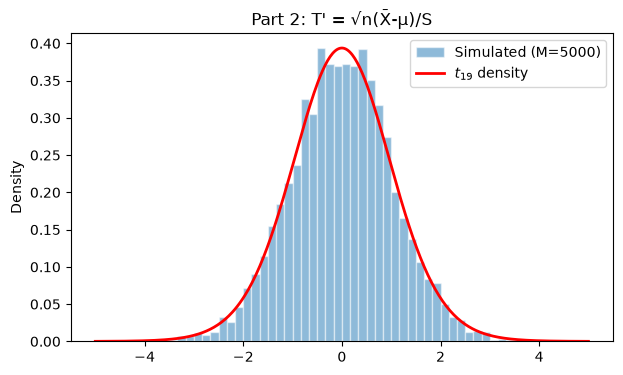

In [9]:
# Part 2: T' vs t with n-1 df
x = np.linspace(-5, 5, 400)
hist_vs_pdf(T_prime, x, stats.t.pdf(x, df=n-1),
            "Part 2: T' = √n(X̄-μ)/S", r"$t_{19}$ density", range_=(-5, 5))

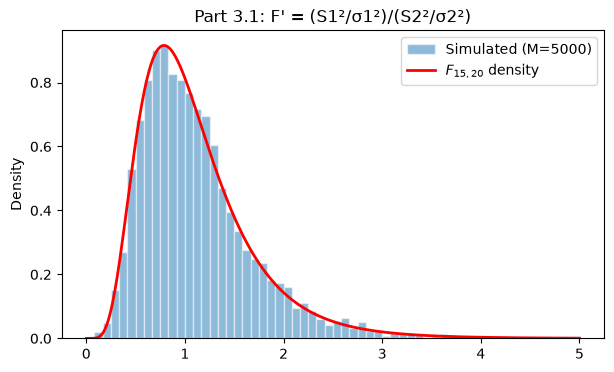

In [10]:
# Part 3.1: two samples, F'
n1, n2 = 16, 21
mu1, mu2 = 3, -2
s1, s2 = 2, 3

X = rng.normal(mu1, s1, size=(M, n1))
Y = rng.normal(mu2, s2, size=(M, n2))

S1_sq = X.var(axis=1, ddof=1)
S2_sq = Y.var(axis=1, ddof=1)
F_prime = (S1_sq / s1**2) / (S2_sq / s2**2)

x = np.linspace(0.001, 5, 400)
hist_vs_pdf(F_prime, x, stats.f.pdf(x, dfn=n1-1, dfd=n2-1),
            "Part 3.1: F' = (S1²/σ1²)/(S2²/σ2²)", r"$F_{15,20}$ density", range_=(0, 5))